# Preprocessor Attention Pipeline

This notebook is the eighth step in the sequence. The earlier notebooks assumed that a useful preimage graph already existed. This notebook covers the earlier step: how `abstractgraph.preprocessor` turns token-level inputs and attention structure into a base NetworkX graph that can then enter the operator pipeline.

Previous: [07 Vectorization And Features](./example_abstract_graph_operators_07_vectorization_and_features.ipynb)  
Next: [09 Feature Inspection And Subgraphs](./example_abstract_graph_operators_09_feature_inspection_and_subgraphs.ipynb)


## What this notebook is really about

The preprocessor is not mainly another operator. It is graph construction policy. The central question is:

> Given token embeddings or attention-like affinities, how do we induce a preimage graph that is stable enough to support downstream decomposition?

We will therefore separate two layers:

1. the graph extraction helper `build_preimage_edges_from_attention(...)`
2. the end-to-end wrapper `AbstractGraphPreprocessor`


In [1]:
from pathlib import Path
import runpy

def _find_notebook_bootstrap(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        direct = candidate / "notebooks" / "_bootstrap.py"
        if direct.exists():
            return direct
        nested = candidate / "abstractgraph" / "notebooks" / "_bootstrap.py"
        if nested.exists():
            return nested
    raise FileNotFoundError("Could not locate notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_find_notebook_bootstrap(Path.cwd())))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.core.display import HTML
from warnings import simplefilter

simplefilter(action='ignore', category=FutureWarning)
HTML('<style>.container { width:95% !important; }</style>')


In [3]:
from abstractgraph.preprocessor import (
    build_preimage_edges_from_attention,
    AbstractGraphPreprocessor,
    ImageNodeClusterer,
)
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.display import display, display_decomposition_graph, display_graph, display_mappings
from abstractgraph.operators import *


def draw(graph, decomposition_function, *, nbits=8, size=(12, 6), n_elements_per_row=8):
    display_decomposition_graph(decomposition_function)
    ag = graph_to_abstract_graph(graph, decomposition_function=decomposition_function, nbits=nbits)
    display(ag, size=size)
    display_mappings(ag, n_elements_per_row=n_elements_per_row)
    return ag


## Start from a hand-crafted attention matrix

Before training anything, it helps to see the extraction logic directly. The matrix below encodes three local groups with stronger within-group affinities than between-group affinities.


In [4]:
W = np.array([
    [1.00, 0.92, 0.15, 0.10, 0.05, 0.02],
    [0.92, 1.00, 0.18, 0.12, 0.05, 0.03],
    [0.15, 0.18, 1.00, 0.88, 0.20, 0.08],
    [0.10, 0.12, 0.88, 1.00, 0.22, 0.10],
    [0.05, 0.05, 0.20, 0.22, 1.00, 0.91],
    [0.02, 0.03, 0.08, 0.10, 0.91, 1.00],
], dtype=float)

pd.DataFrame(W)


,0,1,2,3,4,5
0,1.00,0.92,0.15,0.10,0.05,0.02
1,0.92,1.00,0.18,0.12,0.05,0.03
2,0.15,0.18,1.00,0.88,0.20,0.08
3,0.10,0.12,0.88,1.00,0.22,0.10
4,0.05,0.05,0.20,0.22,1.00,0.91
5,0.02,0.03,0.08,0.10,0.91,1.00


## Build preimage edges directly

`build_preimage_edges_from_attention(...)` applies the MST-plus-DP consensus procedure and returns both an edge list and a co-clustering matrix.


In [5]:
edge_list, co_cluster = build_preimage_edges_from_attention(
    W,
    K_mst=2,
    alpha=1.0,
    beta=0.2,
    rho=0.5,
)
print('n_edges =', len(edge_list))
pd.DataFrame(edge_list, columns=['u', 'v', 'attr']).head()


n_edges = 7


,u,v,attr
0,0,1,"{'consensus': 0.5, 'weight': 0.5, 'mst_count':..."
1,2,3,"{'consensus': 0.5, 'weight': 0.5, 'mst_count':..."
2,2,4,"{'consensus': 1.0, 'weight': 1.0, 'mst_count':..."
3,2,5,"{'consensus': 0.5, 'weight': 0.5}"
4,3,4,"{'consensus': 0.5, 'weight': 0.5, 'mst_count':..."


## Inspect the consensus matrix

This matrix records how often tokens end up co-clustered across the extracted forests.


In [6]:
pd.DataFrame(co_cluster)


,0,1,2,3,4,5
0,1.0,0.5,0.0,0.0,0.0,0.0
1,0.5,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.5,1.0,0.5
3,0.0,0.0,0.5,1.0,0.5,0.5
4,0.0,0.0,1.0,0.5,1.0,0.5
5,0.0,0.0,0.5,0.5,0.5,1.0


## Turn the extracted edges into a preimage graph

This graph is still just a plain NetworkX graph. That is important: preprocessing creates the base graph, it does not skip directly to an `AbstractGraph`.


Graph with 6 nodes and 7 edges


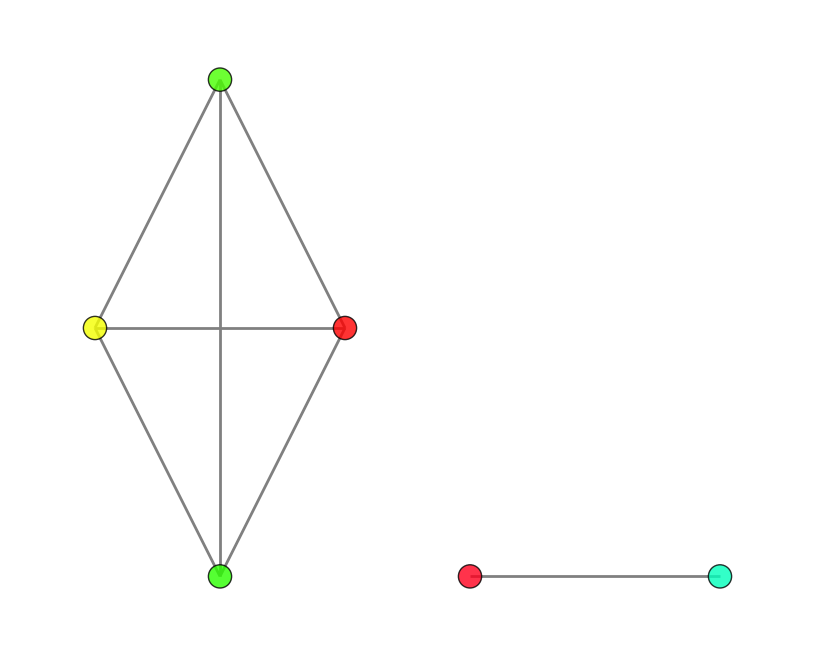

In [7]:
manual_graph = nx.Graph()
for i in range(W.shape[0]):
    manual_graph.add_node(i, label=f'tok_{i}')
manual_graph.add_edges_from(edge_list)
manual_graph.graph['co_cluster'] = co_cluster

print(manual_graph)
display_graph(manual_graph)


## Parameter sensitivity

The extraction is controlled mainly by `K_mst`, `beta`, and `rho`. Lower `rho` tends to admit more consensus edges. Larger `beta` penalizes keeping edges and can collapse the graph toward emptier forests.


In [8]:
for params in [
    {'K_mst': 1, 'alpha': 1.0, 'beta': 0.2, 'rho': 0.5},
    {'K_mst': 3, 'alpha': 1.0, 'beta': 0.2, 'rho': 0.8},
    {'K_mst': 3, 'alpha': 1.0, 'beta': 1.5, 'rho': 0.5},
]:
    edges, _ = build_preimage_edges_from_attention(W, **params)
    print(params, '->', len(edges), 'edges')


{'K_mst': 1, 'alpha': 1.0, 'beta': 0.2, 'rho': 0.5} -> 7 edges
{'K_mst': 3, 'alpha': 1.0, 'beta': 0.2, 'rho': 0.8} -> 5 edges
{'K_mst': 3, 'alpha': 1.0, 'beta': 1.5, 'rho': 0.5} -> 0 edges


## Move to the end-to-end wrapper

Now we switch from a hand-crafted affinity matrix to `AbstractGraphPreprocessor`, which learns token embeddings with a tiny transformer and then extracts a preimage graph from the resulting attention.


## A tiny synthetic token dataset

Each instance is a matrix of token embeddings with shape `(n_tokens, d_in)`. We use two simple classes with slightly different token patterns so the notebook stays self-contained and trains quickly.


In [9]:
rng = np.random.default_rng(0)

base_a = np.array([
    [ 2.0,  0.0,  0.0,  0.0],
    [ 2.1,  0.1,  0.0,  0.0],
    [ 0.0,  2.0,  0.0,  0.0],
    [ 0.0,  2.1,  0.1,  0.0],
    [-2.0,  0.0,  0.0,  0.0],
    [-2.1, -0.1,  0.0,  0.0],
], dtype='float32')

base_b = np.array([
    [ 0.0,  0.0,  2.0,  0.0],
    [ 0.1,  0.0,  2.1,  0.0],
    [ 0.0,  0.0,  0.0,  2.0],
    [ 0.1,  0.0,  0.0,  2.1],
    [ 0.0,  0.0, -2.0,  0.0],
    [ 0.0, -0.1, -2.1,  0.0],
], dtype='float32')

X = []
y = []
for _ in range(4):
    X.append((base_a + 0.05 * rng.normal(size=base_a.shape)).astype('float32'))
    y.append(0)
for _ in range(4):
    X.append((base_b + 0.05 * rng.normal(size=base_b.shape)).astype('float32'))
    y.append(1)

y = np.asarray(y)
print(len(X), y)
print(X[0].shape)


8 [0 0 0 0 1 1 1 1]
(6, 4)


## A label function for preimage nodes

`AbstractGraphPreprocessor` calls `label_fn(x_instance, [token_index])` for each token node, so the function needs exactly that signature.


In [10]:
def label_fn(x_instance, token_indices):
    i = token_indices[0]
    return f'tok_{i}'


## Fit the preprocessor

We keep the model deliberately small: one layer, low-dimensional hidden state, CPU, and only a couple of epochs.


In [11]:
pp = AbstractGraphPreprocessor(
    d_model=8,
    n_heads=2,
    num_layers=1,
    dim_feedforward=16,
    dropout=0.0,
    K_mst=2,
    alpha=1.0,
    beta=0.1,
    rho=0.2,
    n_epochs=2,
    lr=1e-3,
    device='cpu',
    label_fn=label_fn,
)

pp.fit(X, y)


,d_model,8
,n_heads,2
,num_layers,1
,dim_feedforward,16
,dropout,0.0
,K_mst,2
,alpha,1.0
,beta,0.1
,rho,0.2
,n_epochs,2
,lr,0.001


## Transform token matrices into preimage graphs

The output of `transform(...)` is a list of NetworkX graphs. Their nodes carry learned embeddings and labels. Their edges carry extraction metadata.


In [12]:
graphs = pp.transform(X[:2])
[g.number_of_nodes() for g in graphs], [g.number_of_edges() for g in graphs]


([6, 6], [15, 15])

Graph with 6 nodes and 15 edges


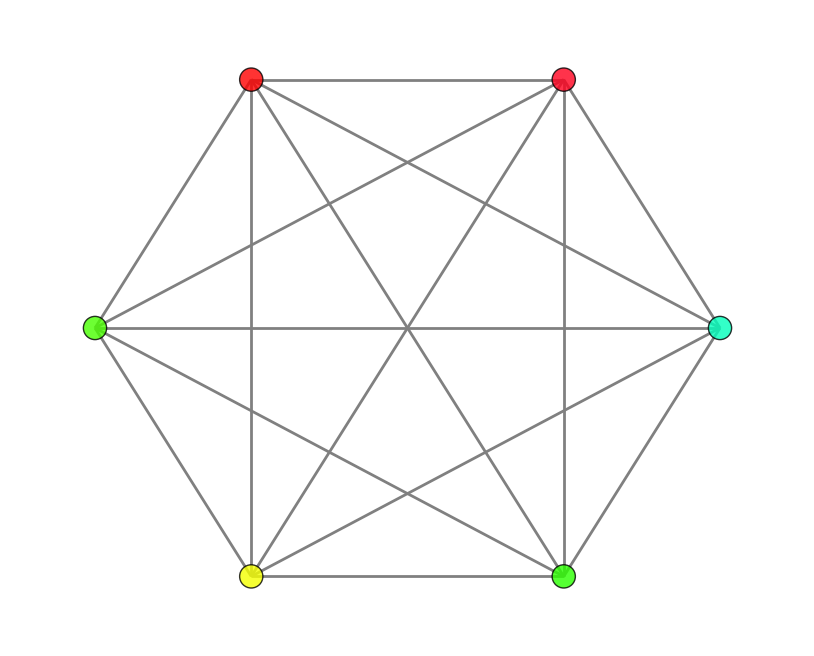

In [13]:
preimage_graph = graphs[0]
print(preimage_graph)
display_graph(preimage_graph)


## Inspect node, edge, and graph attributes

This is the main payload of the preprocessor stage.


In [14]:
first_node = list(preimage_graph.nodes(data=True))[0]
print('node keys:', sorted(first_node[1].keys()))
print('label:', first_node[1]['label'])
print('embedding shape:', np.asarray(first_node[1]['embedding']).shape)

first_edge = list(preimage_graph.edges(data=True))[0]
print('edge keys:', sorted(first_edge[2].keys()))
print('graph keys:', sorted(preimage_graph.graph.keys()))
print('co_cluster shape:', np.asarray(preimage_graph.graph['co_cluster']).shape)


node keys: ['embedding', 'label']
label: tok_0
embedding shape: (8,)
edge keys: ['consensus', 'mst_count', 'mst_weight_mean', 'weight']
graph keys: ['co_cluster']
co_cluster shape: (6, 6)


## Compare `rho` on the same dataset

This is the wrapper-level version of the earlier helper experiment. A lower `rho` admits denser consensus connectivity, while a higher `rho` can leave only MST-supported edges or none at all.


In [15]:
for rho in [0.0, 0.2, 0.8]:
    pp_rho = AbstractGraphPreprocessor(
        d_model=8,
        n_heads=2,
        num_layers=1,
        dim_feedforward=16,
        dropout=0.0,
        K_mst=2,
        alpha=1.0,
        beta=0.1,
        rho=rho,
        n_epochs=2,
        lr=1e-3,
        device='cpu',
        label_fn=label_fn,
    )
    pp_rho.fit(X, y)
    g = pp_rho.transform(X[:1])[0]
    print('rho =', rho, '->', g.number_of_edges(), 'edges')


rho = 0.0 -> 15 edges
rho = 0.2 -> 15 edges
rho = 0.8 -> 15 edges


## Optional dataset-level clustering

If you want coarse node types after graph construction, you can cluster the learned node embeddings across a dataset and write `cluster_id` back onto each preimage node.


In [16]:
cluster_pp = AbstractGraphPreprocessor(
    d_model=8,
    n_heads=2,
    num_layers=1,
    dim_feedforward=16,
    dropout=0.0,
    K_mst=2,
    alpha=1.0,
    beta=0.1,
    rho=0.2,
    n_epochs=2,
    lr=1e-3,
    device='cpu',
    label_fn=label_fn,
    node_clusterer=ImageNodeClusterer(n_clusters=3, random_state=0),
)
cluster_pp.fit(X, y)
cluster_graphs = cluster_pp.transform(X[:2])
cluster_graphs = cluster_pp.assign_node_cluster_labels(cluster_graphs)
list(cluster_graphs[0].nodes(data=True))[:3]


[(0,
  {'embedding': array([ 0.4936027 ,  0.9917771 ,  0.7825708 , -0.7147307 , -1.0535796 ,
           0.82297075,  0.5649555 , -1.8786129 ], dtype=float32),
   'label': 'tok_0',
   'cluster_id': 0}),
 (1,
  {'embedding': array([ 0.51688594,  0.99264723,  0.8820066 , -0.6811746 , -1.0328084 ,
           0.76734596,  0.46510255, -1.9010655 ], dtype=float32),
   'label': 'tok_1',
   'cluster_id': 0}),
 (2,
  {'embedding': array([ 1.2805128 ,  0.96685773,  0.16507229, -1.1996309 , -0.26214883,
          -0.03959531,  0.87129015, -1.7624149 ], dtype=float32),
   'label': 'tok_2',
   'cluster_id': 2})]

## Hand the preprocessed graph into the operator pipeline

This is the bridge back to the rest of the sequence. Once you have a preimage graph, the downstream workflow is the same as before.


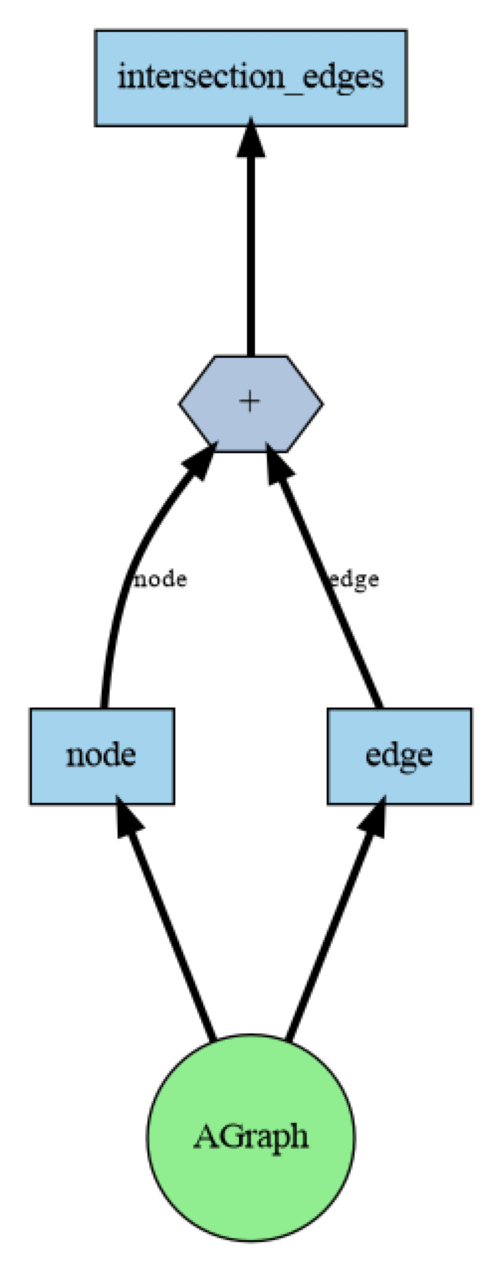

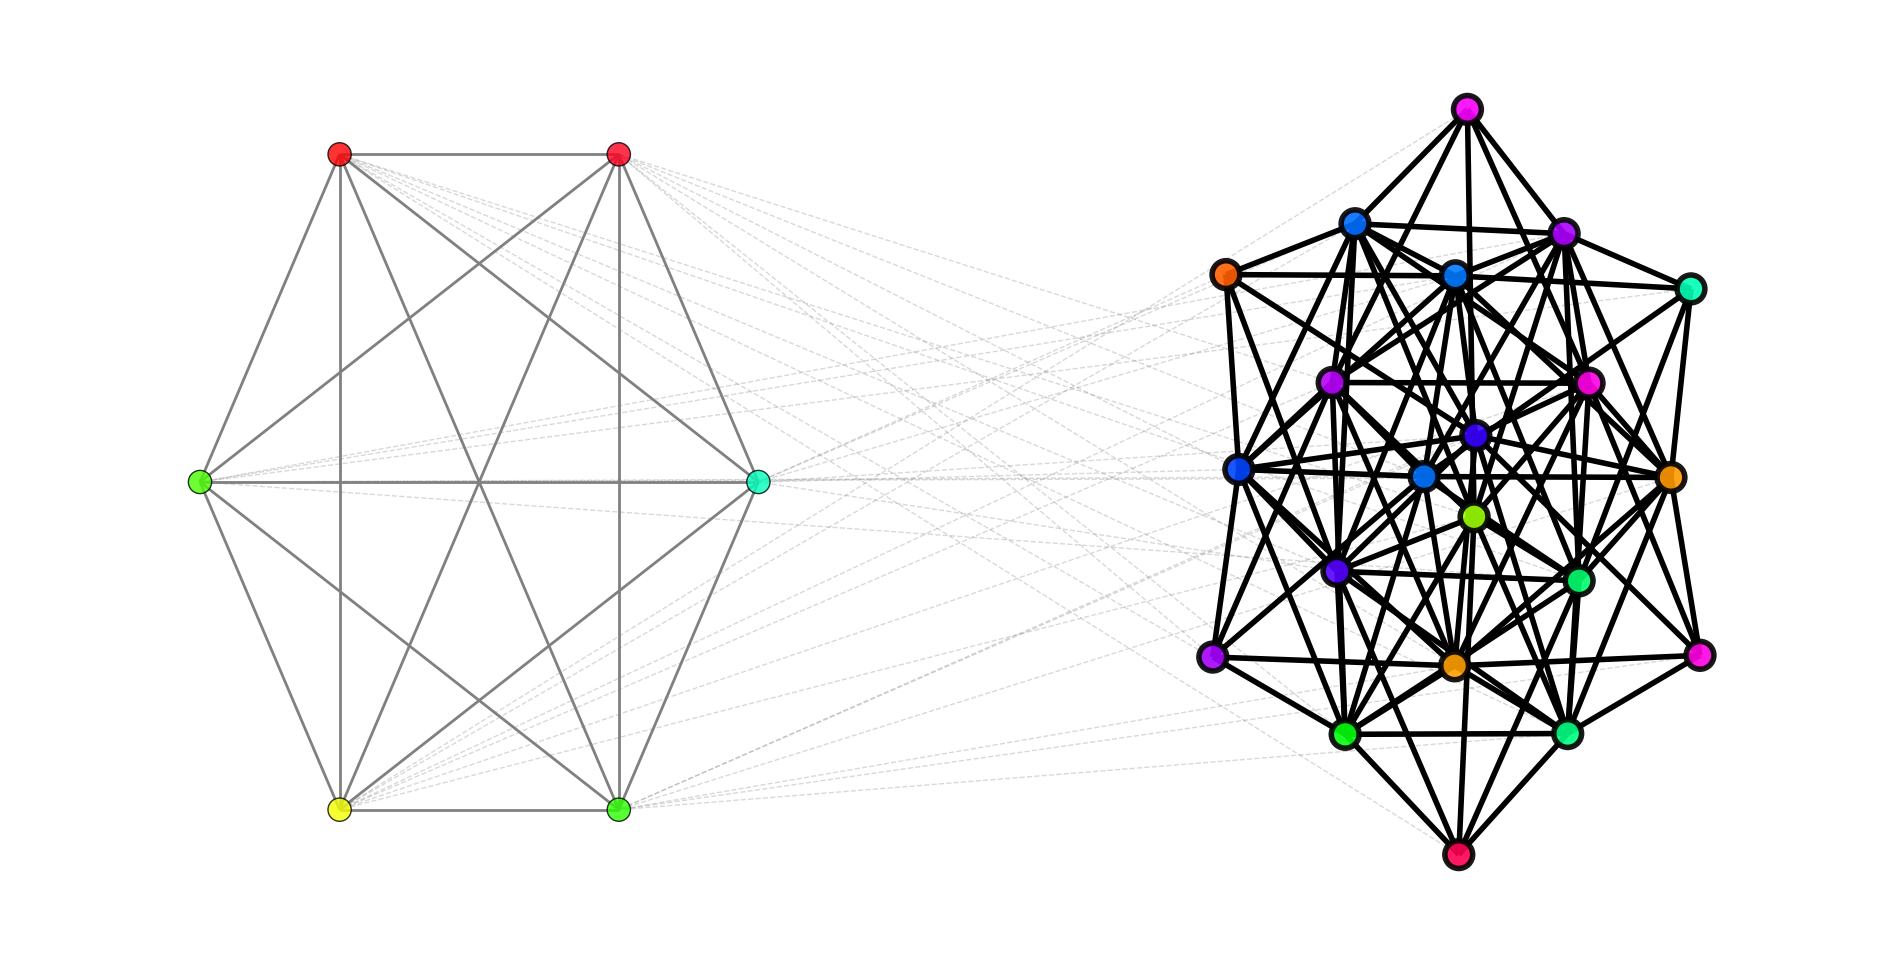

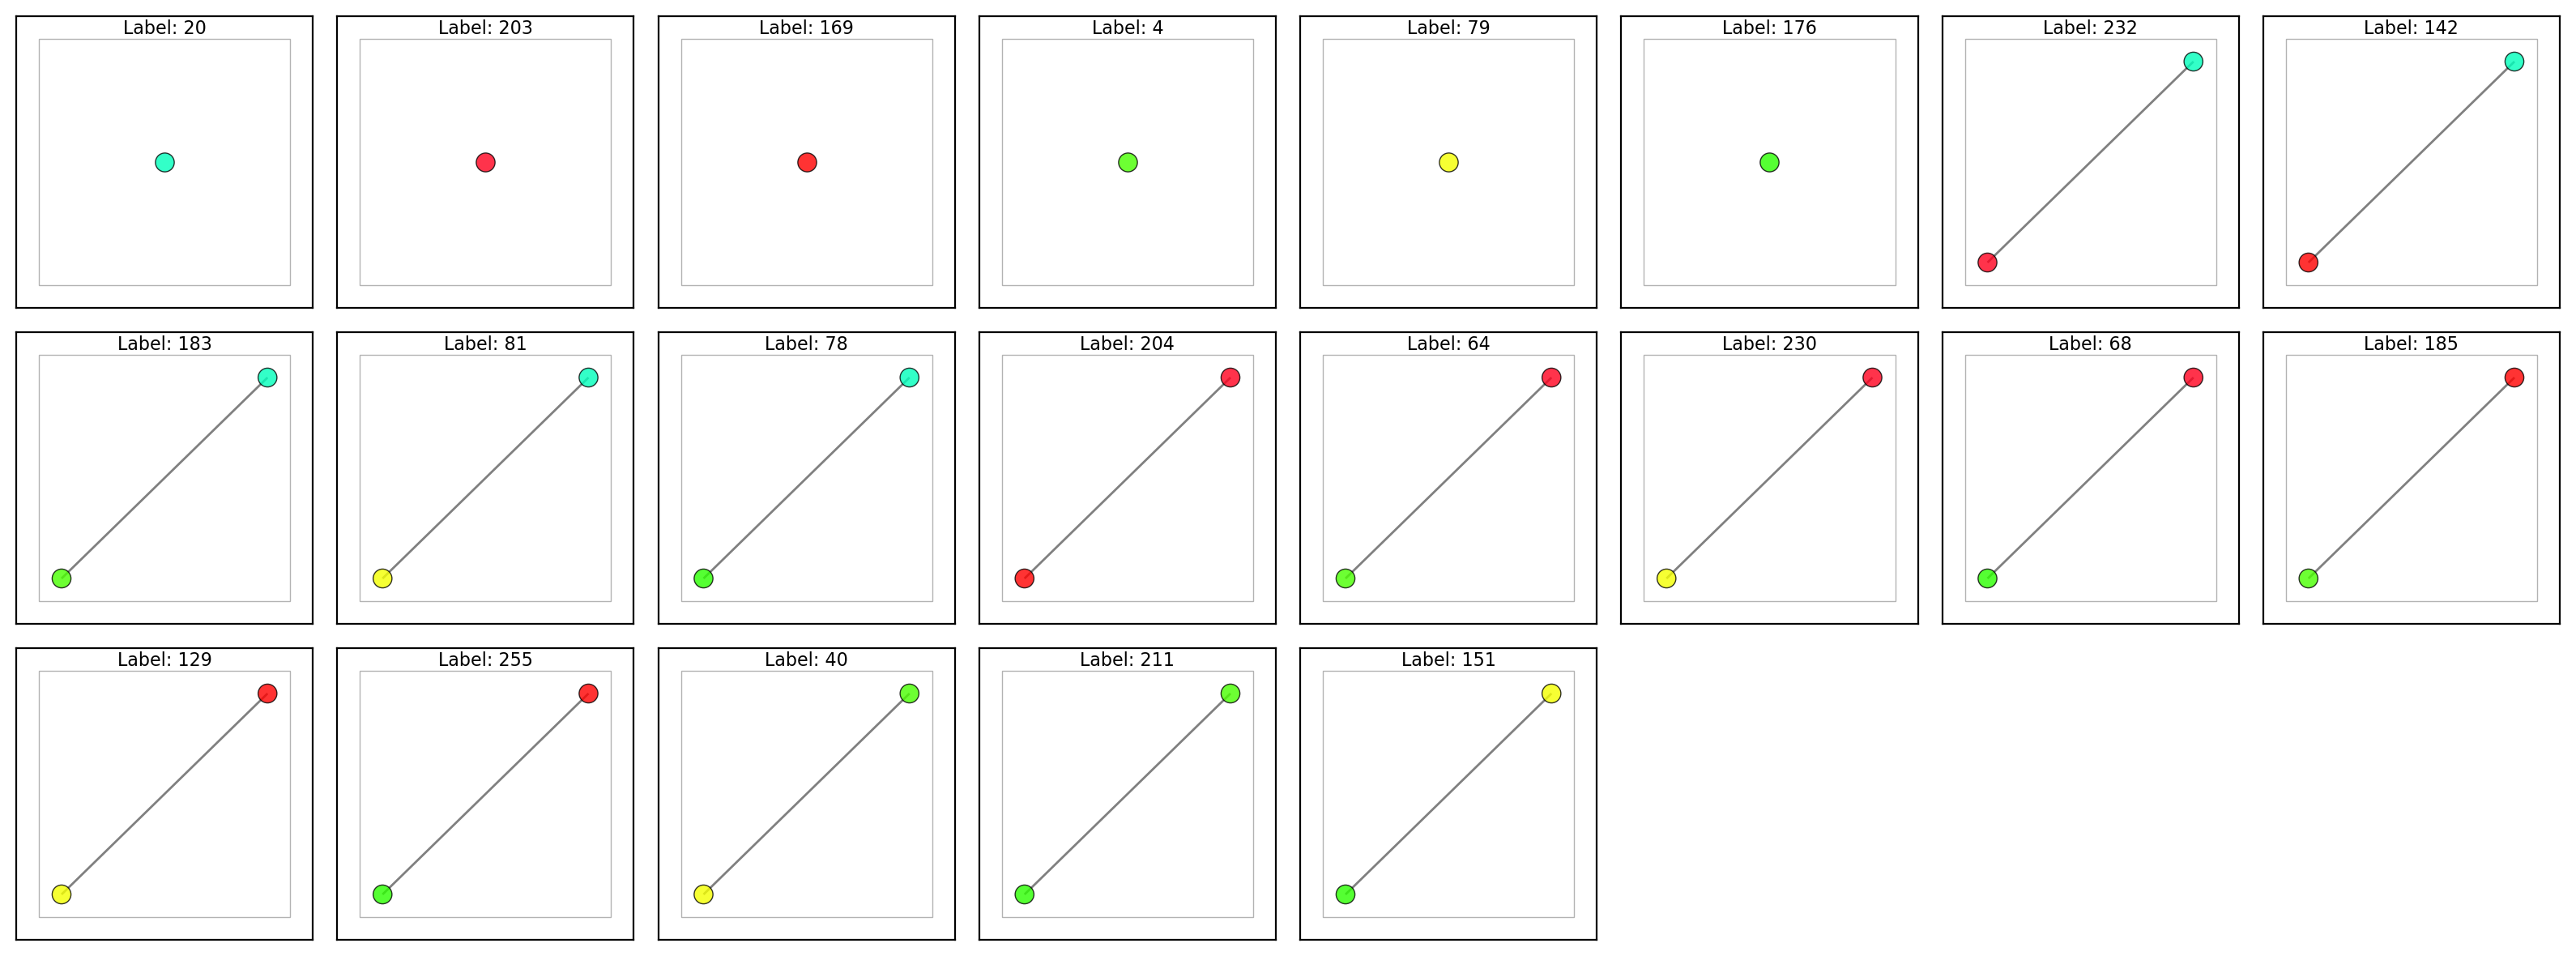

In [17]:
df = compose(intersection_edges(), add(node(), edge()))
preprocessed_ag = draw(preimage_graph, df, nbits=8)


## Summary

The preprocessor stage answers a different question from the operator stage. Operators ask how to decompose a graph once it exists. The preprocessor asks how to induce that graph from token-level signal in the first place.

The practical workflow is:

1. learn or receive token embeddings
2. extract a preimage graph from attention structure
3. inspect node and edge metadata
4. pass the resulting graph into the standard `AbstractGraph` operator pipeline

Previous: [07 Vectorization And Features](./example_abstract_graph_operators_07_vectorization_and_features.ipynb)  
Next: [09 Feature Inspection And Subgraphs](./example_abstract_graph_operators_09_feature_inspection_and_subgraphs.ipynb)
